In [1]:
# pacakgee imports
import importlib
from pathlib import Path

import SUAVE
assert SUAVE.__version__=='2.5.2', 'These tutorials only work with the SUAVE 2.5.2 release'
import numpy as np

# module imports
from SUAVE.Core                                          import Units, Data
from SUAVE.Attributes.Gases                              import Air
from SUAVE.Plots.Performance.Mission_Plots               import *
from SUAVE.Input_Output.OpenVSP                          import write
from SUAVE.Methods.Geometry.Two_Dimensional.Planform     import segment_properties, wing_segmented_planform, wing_planform
from SUAVE.Methods.Propulsion                            import propeller_design
from SUAVE.Methods.Propulsion.electric_motor_sizing      import size_optimal_motor
from SUAVE.Methods.Power.Battery.Sizing                  import initialize_from_mass

from copy import deepcopy


# # Compatibility fix for SUAVE 2.5.2 airfoil post-stall indexing
# # The stock function uses a list-wrapped boolean mask in one branch, which can
# # raise an IndexError during propeller_design().
# def _fixed_post_stall_coefficients(state, settings, geometry):
#     wing   = geometry
#     A0     = settings.section_zero_lift_angle_of_attack
#     AR     = wing.aspect_ratio
#     t_c    = wing.thickness_to_chord
#     ACL1   = wing.section.angle_attack_max_prestall_lift
#     CD1max = wing.pre_stall_maximum_lift_drag_coefficient
#     ACD1   = wing.pre_stall_maximum_drag_coefficient_angle
#     alpha  = state.conditions.aerodynamics.angle_of_attack

#     if wing.vertical == True:
#         alpha = 0. * np.ones_like(alpha)

#     F1     = 1.190 * (1.0 - (t_c * t_c))
#     F2     = 0.65 + 0.35 * np.exp(-(9.0 / AR) ** 2.3)
#     G1     = 2.3 * np.exp(-(0.65 * t_c) ** 0.9)
#     G2     = 0.52 + 0.48 * np.exp(-(6.5 / AR) ** 1.1)
#     CL2max = F1 * F2
#     CD2max = G1 * G2
#     RCL2   = 1.632 - CL2max
#     N2     = 1 + CL2max / RCL2

#     con1      = np.logical_and(0 < alpha, alpha < ACL1)
#     con2      = np.logical_and(ACL1 <= alpha, alpha <= (92.0 * Units.deg))
#     con3      = alpha >= (92.0 * Units.deg)
#     CL2       = np.zeros_like(alpha)
#     CL2[con1] = 0
#     CL2[con2] = -0.032 * (alpha[con2] / Units.deg - 92.0) - RCL2 * ((92.0 * Units.deg - alpha[con2]) / (51.0 * Units.deg)) ** N2
#     CL2[con3] = -0.032 * (alpha[con3] / Units.deg - 92.0) + RCL2 * ((alpha[con3] - 92.0 * Units.deg) / (51.0 * Units.deg)) ** N2

#     alphan    = -alpha + 2 * A0
#     con1      = np.logical_and(0 < alphan, alphan < ACL1)
#     con2      = np.logical_and(ACL1 <= alphan, alphan <= (92.0 * Units.deg))
#     con3      = alphan >= (92.0 * Units.deg)
#     CL2[con1] = 0.
#     CL2[con2] = 0.032 * (alphan[con2] / Units.deg - 92.0) + RCL2 * ((92.0 * Units.deg - alphan[con2]) / (51.0 * Units.deg)) ** N2
#     CL2[con3] = 0.032 * (alphan[con3] / Units.deg - 92.0) - RCL2 * ((alphan[con3] - 92.0 * Units.deg) / (51.0 * Units.deg)) ** N2

#     con1      = np.logical_and((2 * A0 - ACL1) < alpha, alpha < ACL1)
#     con2      = alpha > ACD1
#     CD2       = 0.0 * np.ones_like(alpha)
#     CD2[con1] = 0.
#     CD2[con2] = CD1max[con2] + (CD2max - CD1max[con2]) * np.sin((alpha[con2] - ACD1[con2]) / (np.pi / 2 - ACD1[con2]))

#     alphan    = -alpha + 2 * A0
#     con1      = np.logical_and((2 * A0 - ACL1) < alphan, alphan < ACL1)
#     con2      = alphan >= ACD1
#     CD2[con1] = 0.
#     CD2[con2] = CD1max[con2] + (CD2max - CD1max[con2]) * np.sin((alphan[con2] - ACD1[con2]) / (np.pi / 2 - ACD1[con2]))

#     wing_result = Data(
#         lift_coefficient=CL2,
#         drag_coefficient=CD2,
#     )

#     state.conditions.aerodynamics.post_stall_coefficients[wing.tag] = wing_result
#     return CL2, CD2

# _psc_mod  = importlib.import_module('SUAVE.Methods.Aerodynamics.AERODAS.post_stall_coefficients')
# _cap_mod  = importlib.import_module('SUAVE.Methods.Geometry.Two_Dimensional.Cross_Section.Airfoil.compute_airfoil_polars')
# _prop_mod = importlib.import_module('SUAVE.Methods.Propulsion.propeller_design')

# _psc_mod.post_stall_coefficients = _fixed_post_stall_coefficients
# _cap_mod.post_stall_coefficients = _fixed_post_stall_coefficients
# _cap_mod.compute_airfoil_polars.__globals__['post_stall_coefficients'] = _fixed_post_stall_coefficients
# _prop_mod.compute_airfoil_polars.__globals__['post_stall_coefficients'] = _fixed_post_stall_coefficients


# # Compatibility fix for missing NMC battery response-surface data in some SUAVE installs
# _nmc_mod = importlib.import_module(
#     'SUAVE.Components.Energy.Storages.Batteries.Constant_Mass.Lithium_Ion_LiNiMnCoO2_18650'
# )
# _NMCBattery = _nmc_mod.Lithium_Ion_LiNiMnCoO2_18650
# _original_nmc_defaults = _NMCBattery.__defaults__

# def _fixed_nmc_defaults(self):
#     _original_nmc_defaults(self)
#     if getattr(self, 'discharge_performance_map', None) is None:
#         nmc_data_path = Path(r'd:/Workspace/SUAVE-2.5.2/trunk/SUAVE/Components/Energy/Storages/Batteries/Constant_Mass/NMC_Raw_Data.res')
#         if nmc_data_path.exists():
#             raw_data = SUAVE.Input_Output.SUAVE.load(str(nmc_data_path))
#             self.discharge_performance_map = _nmc_mod.create_discharge_performance_map(raw_data)

# _NMCBattery.__defaults__ = _fixed_nmc_defaults


In [2]:
def setup_vehicle():
    
    # ------------------------------------------------------------------
    #   Initialize the Vehicle
    # ------------------------------------------------------------------    
    
    # Create a vehicle and set level properties
    vehicle               = SUAVE.Vehicle()
    vehicle.tag           = 'eVTOL'
    
    # ------------------------------------------------------------------
    #   Vehicle-level Properties
    # ------------------------------------------------------------------
    # mass properties
    vehicle.mass_properties.takeoff           = 2500. * Units.lb
    vehicle.mass_properties.operating_empty   = 2150. * Units.lb       
    vehicle.mass_properties.max_takeoff       = 2500. * Units.lb     
    vehicle.mass_properties.max_payload       = 100.  * Units.lb
    vehicle.mass_properties.center_of_gravity = [[2.0,   0.  ,  0. ]] # I made this up
    
    # basic parameters
    vehicle.envelope.ultimate_load = 5.7
    vehicle.envelope.limit_load    = 3.    
    
    # ------------------------------------------------------------------
    # WINGS
    # ------------------------------------------------------------------
    # WING PROPERTIES
    wing                          = SUAVE.Components.Wings.Main_Wing()
    wing.tag                      = 'main_wing'
    wing.origin                   = [[1.5, 0., -0.5 ]]
    wing.spans.projected          = 35.0   * Units.feet
    wing.chords.root              = 3.25   * Units.feet

    # Segment
    segment                       = SUAVE.Components.Wings.Segment()
    segment.tag                   = 'Root'
    segment.percent_span_location = 0.
    segment.twist                 = 0.
    segment.root_chord_percent    = 1.5
    segment.dihedral_outboard     = 1.0 * Units.degrees
    segment.sweeps.quarter_chord  = 8.5 * Units.degrees
    segment.thickness_to_chord    = 0.18
    wing.Segments.append(segment)

    # Segment
    segment                       = SUAVE.Components.Wings.Segment()
    segment.tag                   = 'Section_2'
    segment.percent_span_location = 0.227
    segment.twist                 = 0.
    segment.root_chord_percent    = 1.
    segment.dihedral_outboard     = 1.0  * Units.degrees
    segment.sweeps.quarter_chord  = 0.0  * Units.degrees
    segment.thickness_to_chord    = 0.12
    wing.Segments.append(segment)

    # Segment
    segment                       = SUAVE.Components.Wings.Segment()
    segment.tag                   = 'Tip'
    segment.percent_span_location = 1.0
    segment.twist                 = 0.
    segment.root_chord_percent    = 1.0
    segment.dihedral_outboard     = 0.0 * Units.degrees
    segment.sweeps.quarter_chord  = 0.0 * Units.degrees
    segment.thickness_to_chord    = 0.12
    wing.Segments.append(segment)
    
    # Fill out more segment properties automatically
    wing = segment_properties(wing)
    wing =  wing_segmented_planform(wing)
    
    
    ## ALSO SET THE VEHICLE REFERENCE AREA
    vehicle.reference_area         = wing.areas.reference

    # add to vehicle
    vehicle.append_component(wing)
    
    # Add a horizontal tail
    # WING PROPERTIES
    wing                          = SUAVE.Components.Wings.Horizontal_Tail()
    wing.tag                      = 'horizontal_tail'
    wing.areas.reference          = 2.0
    wing.taper                    = 0.5
    wing.sweeps.quarter_chord     = 20. * Units.degrees
    wing.aspect_ratio             = 5.0
    wing.thickness_to_chord       = 0.12
    wing.dihedral                 = 5.  * Units.degrees
    wing.origin                   = [[5.5 , 0.0 , 0.65 ]]
    
    # Fill out more segment properties automatically
    wing = wing_planform(wing)
    
    # add to vehicle
    vehicle.append_component(wing)    
    
    # Add a vertical tail
    wing                          = SUAVE.Components.Wings.Vertical_Tail()
    wing.tag                      = 'vertical_tail'
    wing.areas.reference          = 1.0
    wing.taper                    = 0.5
    wing.sweeps.quarter_chord     = 30 * Units.degrees
    wing.aspect_ratio             = 2.5
    wing.thickness_to_chord       = 0.12
    wing.origin                   = [[5.5 , 0.0 , 0.65 ]]
    
    # Fill out more segment properties automatically
    wing = wing_planform(wing)
    
    # add to vehicle
    vehicle.append_component(wing)        
    
    # Add a fuseelage
    
    # ---------------------------------------------------------------
    # FUSELAGE
    # ---------------------------------------------------------------
    # FUSELAGE PROPERTIES
    fuselage                                    = SUAVE.Components.Fuselages.Fuselage()
    fuselage.tag                                = 'fuselage'
    fuselage.seats_abreast                      = 2.
    fuselage.fineness.nose                      = 0.88
    fuselage.fineness.tail                      = 1.13
    fuselage.lengths.nose                       = 3.2 * Units.feet
    fuselage.lengths.tail                       = 6.4 * Units.feet
    fuselage.lengths.cabin                      = 6.4 * Units.feet
    fuselage.lengths.total                      = 6.0
    fuselage.width                              = 5.85 * Units.feet
    fuselage.heights.maximum                    = 4.65 * Units.feet
    fuselage.heights.at_quarter_length          = 3.75 * Units.feet
    fuselage.heights.at_wing_root_quarter_chord = 4.65 * Units.feet
    fuselage.heights.at_three_quarters_length   = 4.26 * Units.feet
    fuselage.areas.wetted                       = 236. * Units.feet**2
    fuselage.areas.front_projected              = 0.14 * Units.feet**2
    fuselage.effective_diameter                 = 5.85 * Units.feet
    fuselage.differential_pressure              = 0.

    # Segment
    segment                           = SUAVE.Components.Lofted_Body_Segment.Segment()
    segment.tag                       = 'segment_0'
    segment.percent_x_location        = 0.
    segment.percent_z_location        = -0.05
    segment.height                    = 0.1
    segment.width                     = 0.1
    fuselage.Segments.append(segment)

    # Segment
    segment                           = SUAVE.Components.Lofted_Body_Segment.Segment()
    segment.tag                       = 'segment_1'
    segment.percent_x_location        = 0.06
    segment.percent_z_location        = -0.05
    segment.height                    = 0.52
    segment.width                     = 0.75
    fuselage.Segments.append(segment)

    # Segment
    segment                           = SUAVE.Components.Lofted_Body_Segment.Segment()
    segment.tag                       = 'segment_2'
    segment.percent_x_location        =  0.25
    segment.percent_z_location        = -.01
    segment.height                    =  1.2
    segment.width                     =  1.43
    fuselage.Segments.append(segment)

    # Segment
    segment                           = SUAVE.Components.Lofted_Body_Segment.Segment()
    segment.tag                       = 'segment_3'
    segment.percent_x_location        =  0.475
    segment.percent_z_location        =  0
    segment.height                    =  1.4
    segment.width                     =  1.4
    fuselage.Segments.append(segment)

    # Segment
    segment                           = SUAVE.Components.Lofted_Body_Segment.Segment()
    segment.tag                       = 'segment_4'
    segment.percent_x_location        = 0.75
    segment.percent_z_location        = 0.06
    segment.height                    = 0.6
    segment.width                     = 0.4
    fuselage.Segments.append(segment)

    # Segment
    segment                           = SUAVE.Components.Lofted_Body_Segment.Segment()
    segment.tag                       = 'segment_5'
    segment.percent_x_location        = 1.
    segment.percent_z_location        = 0.1
    segment.height                    = 0.05
    segment.width                     = 0.05
    fuselage.Segments.append(segment)

    # add to vehicle
    vehicle.append_component(fuselage)    
    

    #-------------------------------------------------------------------
    # Booms
    #-------------------------------------------------------------------
    # Add booms for the motors
    boom                                   = SUAVE.Components.Fuselages.Fuselage()
    boom.tag                                = 'boom_R'
    boom.origin                             = [[0.525, 3.0, -0.35]]
    boom.lengths.nose                       = 0.2
    boom.lengths.tail                       = 0.2
    boom.lengths.total                      = 4
    boom.width                              = 0.15
    boom.heights.maximum                    = 0.15
    boom.heights.at_quarter_length          = 0.15
    boom.heights.at_three_quarters_length   = 0.15
    boom.heights.at_wing_root_quarter_chord = 0.15
    boom.effective_diameter                 = 0.15
    boom.areas.wetted                       = 2*np.pi*(0.075)*3.5
    boom.areas.front_projected              = np.pi*0.15
    boom.fineness.nose                      = 0.15/0.2
    boom.fineness.tail                      = 0.15/0.2 
    
    vehicle.append_component(boom)
    
    # Now attach the mirrored boom
    other_boom              = deepcopy(boom)
    other_boom.origin[0][1] = -boom.origin[0][1]
    other_boom.tag          = 'boom_L'
    vehicle.append_component(other_boom)    

    
    #------------------------------------------------------------------
    # Network
    #------------------------------------------------------------------
    net                              = SUAVE.Components.Energy.Networks.Lift_Cruise()
    net.number_of_lift_rotor_engines = 4
    net.number_of_propeller_engines  = 1
    net.identical_propellers         = True
    net.identical_lift_rotors        = True    
    net.voltage                      = 400.    
    
    #------------------------------------------------------------------
    # Electronic Speed Controller
    #------------------------------------------------------------------
    lift_rotor_esc              = SUAVE.Components.Energy.Distributors.Electronic_Speed_Controller()
    lift_rotor_esc.efficiency   = 0.95
    net.lift_rotor_esc          = lift_rotor_esc

    propeller_esc            = SUAVE.Components.Energy.Distributors.Electronic_Speed_Controller()
    propeller_esc.efficiency = 0.95
    net.propeller_esc        = propeller_esc
    
    #------------------------------------------------------------------
    # Payload
    #------------------------------------------------------------------
    payload                      = SUAVE.Components.Energy.Peripherals.Avionics()
    payload.power_draw           = 0.    
    net.payload                  = payload
    
    #------------------------------------------------------------------
    # Avionics
    #------------------------------------------------------------------
    avionics            = SUAVE.Components.Energy.Peripherals.Avionics()
    avionics.power_draw = 300. * Units.watts
    net.avionics        = avionics    
    
    #------------------------------------------------------------------
    # Design Battery
    #------------------------------------------------------------------
    bat                      = SUAVE.Components.Energy.Storages.Batteries.Constant_Mass.Lithium_Ion_LiNiMnCoO2_18650() 
    bat.mass_properties.mass = 1000. * Units.lb 
    bat.max_voltage          = net.voltage   
    initialize_from_mass(bat)    
    net.battery              = bat      
    
    #------------------------------------------------------------------
    # Design Rotors and Propellers
    #------------------------------------------------------------------    
    
    # The tractor propeller
    propeller                        = SUAVE.Components.Energy.Converters.Propeller()
    propeller.origin                 = [[0,0,-0.325]]
    propeller.number_of_blades       = 3
    propeller.tip_radius             = 0.9
    propeller.hub_radius             = 0.1
    propeller.angular_velocity       = 2200 * Units.rpm
    propeller.freestream_velocity    = 100. * Units.knots
    propeller.design_Cl              = 0.7
    propeller.design_altitude        = 5000. * Units.feet
    propeller.design_thrust          = 500.  * Units.lbf
    propeller.airfoil_geometry       = ['../data/Airfoils/NACA_4412.txt']
    propeller.airfoil_polars         = [['../data/Airfoils/Polars/NACA_4412_polar_Re_50000.txt' ,
                                         '../data/Airfoils/Polars/NACA_4412_polar_Re_100000.txt' ,
                                         '../data/Airfoils/Polars/NACA_4412_polar_Re_200000.txt' ,
                                         '../data/Airfoils/Polars/NACA_4412_polar_Re_500000.txt' ,
                                         '../data/Airfoils/Polars/NACA_4412_polar_Re_1000000.txt' ]]    
    propeller.airfoil_polar_stations = np.zeros((20),dtype=np.int8).tolist()
    propeller                        = propeller_design(propeller)
    net.propellers.append(propeller)
    
    # The lift rotors
    lift_rotor                            = SUAVE.Components.Energy.Converters.Lift_Rotor()
    lift_rotor.tip_radius                 = 1.5
    lift_rotor.hub_radius                 = 0.15
    lift_rotor.number_of_blades           = 4
    lift_rotor.design_tip_mach            = 0.65
    lift_rotor.freestream_velocity        = 500. * Units['ft/min']
    lift_rotor.angular_velocity           = lift_rotor.design_tip_mach* Air().compute_speed_of_sound()/lift_rotor.tip_radius
    lift_rotor.design_Cl                  = 0.7
    lift_rotor.design_altitude            = 3000. * Units.feet
    lift_rotor.design_thrust              = 2500*Units.lbf/4
    lift_rotor.variable_pitch             = False
    lift_rotor.airfoil_geometry           = ['../data/Airfoils/NACA_4412.txt']
    lift_rotor.airfoil_polars             = [['../data/Airfoils/Polars/NACA_4412_polar_Re_50000.txt' ,
                                         '../data/Airfoils/Polars/NACA_4412_polar_Re_100000.txt' ,
                                         '../data/Airfoils/Polars/NACA_4412_polar_Re_200000.txt' ,
                                         '../data/Airfoils/Polars/NACA_4412_polar_Re_500000.txt' ,
                                         '../data/Airfoils/Polars/NACA_4412_polar_Re_1000000.txt' ]]   

    lift_rotor.airfoil_polar_stations     = np.zeros((20),dtype=np.int8).tolist()
    lift_rotor                            = propeller_design(lift_rotor)    
    
    # Appending rotors with different origins
    rotations = [1,-1,-1,1]
    origins   = [[0.6,  3., -0.125] ,[4.5, 3.,  -0.125],
                 [0.6, -3., -0.125] ,[4.5, -3.,  -0.125]]

    for ii in range(4):
        lift_rotor          = deepcopy(lift_rotor)
        lift_rotor.tag      = 'lift_rotor'
        lift_rotor.rotation = rotations[ii]
        lift_rotor.origin   = [origins[ii]]
        net.lift_rotors.append(lift_rotor)    
    

    
    #------------------------------------------------------------------
    # Design Motors
    #------------------------------------------------------------------
    # Propeller (Thrust) motor
    propeller_motor                      = SUAVE.Components.Energy.Converters.Motor()
    propeller_motor.efficiency           = 0.95
    propeller_motor.nominal_voltage      = bat.max_voltage
    propeller_motor.mass_properties.mass = 2.0  * Units.kg
    propeller_motor.origin               = propeller.origin
    propeller_motor.propeller_radius     = propeller.tip_radius
    propeller_motor.no_load_current      = 2.0
    propeller_motor                      = size_optimal_motor(propeller_motor,propeller)
    net.propeller_motors.append(propeller_motor)    
    
    # Rotor (Lift) Motor
    lift_rotor_motor                         = SUAVE.Components.Energy.Converters.Motor()
    lift_rotor_motor.efficiency              = 0.85
    lift_rotor_motor.nominal_voltage         = bat.max_voltage*3/4
    lift_rotor_motor.mass_properties.mass    = 3. * Units.kg
    lift_rotor_motor.origin                  = lift_rotor.origin
    lift_rotor_motor.propeller_radius        = lift_rotor.tip_radius
    lift_rotor_motor.gearbox_efficiency      = 1.0
    lift_rotor_motor.no_load_current         = 4.0
    lift_rotor_motor                         = size_optimal_motor(lift_rotor_motor,lift_rotor) 
    
    for _ in range(4):
        lift_rotor_motor = deepcopy(lift_rotor_motor)
        lift_rotor_motor.tag = 'motor'
        net.lift_rotor_motors.append(lift_rotor_motor)    
        
    
    vehicle.append_component(net)
    
    
    # Now account for things that have been overlooked for now:
    vehicle.excrescence_area = 0.1
    
    return vehicle

In [3]:
# ----------------------------------------------------------------------------------------------------------------------
#   Analyses
# ----------------------------------------------------------------------------------------------------------------------


def setup_analyses(vehicle):
    # ------------------------------------------------------------------
    #   Initialize the Analyses
    # ------------------------------------------------------------------
    analyses = SUAVE.Analyses.Vehicle()

    # ------------------------------------------------------------------
    #  Weights
    weights = SUAVE.Analyses.Weights.Weights_eVTOL()
    weights.vehicle = vehicle
    analyses.append(weights)

    # ------------------------------------------------------------------
    #  Aerodynamics Analysis
    aerodynamics = SUAVE.Analyses.Aerodynamics.Fidelity_Zero()
    aerodynamics.geometry = vehicle
    aerodynamics.settings.drag_coefficient_increment = 0.4 * vehicle.excrescence_area/vehicle.reference_area
    analyses.append(aerodynamics)

    # ------------------------------------------------------------------
    #  Energy
    energy= SUAVE.Analyses.Energy.Energy()
    energy.network = vehicle.networks
    analyses.append(energy)
    
    # ------------------------------------------------------------------
    #  Noise Analysis
    noise = SUAVE.Analyses.Noise.Fidelity_One()
    noise.geometry = vehicle
    analyses.append(noise)

    # ------------------------------------------------------------------
    #  Planet Analysis
    planet = SUAVE.Analyses.Planets.Planet()
    analyses.append(planet)

    # ------------------------------------------------------------------
    #  Atmosphere Analysis
    atmosphere = SUAVE.Analyses.Atmospheric.US_Standard_1976()
    atmosphere.features.planet = planet.features
    analyses.append(atmosphere)

    return analyses



In [4]:

# ----------------------------------------------------------------------------------------------------------------------
#   Mission
# ----------------------------------------------------------------------------------------------------------------------

def setup_mission(vehicle,analyses):
    
    # ------------------------------------------------------------------
    #   Initialize the Mission
    # ------------------------------------------------------------------
    mission            = SUAVE.Analyses.Mission.Sequential_Segments()
    mission.tag        = 'the_mission'   
    
    # unpack Segments module
    Segments                                                 = SUAVE.Analyses.Mission.Segments

    # base segment
    base_segment                                             = Segments.Segment()
    base_segment.state.numerics.number_control_points        = 8
    base_segment.process.initialize.initialize_battery       = SUAVE.Methods.Missions.Segments.Common.Energy.initialize_battery
    base_segment.process.iterate.conditions.planet_position  = SUAVE.Methods.skip   
    base_segment.process.iterate.conditions.stability        = SUAVE.Methods.skip
    base_segment.process.finalize.post_process.stability     = SUAVE.Methods.skip      
    ones_row                                                 = base_segment.state.ones_row
    
    # ------------------------------------------------------------------
    #   Hover Climb Segment
    # ------------------------------------------------------------------
    segment     = Segments.Hover.Climb(base_segment)
    segment.tag = "hover_climb"
    segment.analyses.extend(analyses)
    segment.altitude_start                                   = 0.0   * Units.ft
    segment.altitude_end                                     = 100.  * Units.ft
    segment.climb_rate                                       = 200.  * Units['ft/min']
    segment.battery_energy                                   = vehicle.networks.lift_cruise.battery.max_energy*0.95
    segment.process.iterate.unknowns.mission                 = SUAVE.Methods.skip
    segment = vehicle.networks.lift_cruise.add_lift_unknowns_and_residuals_to_segment(segment)
    
    # add to misison
    mission.append_segment(segment)
    
    # ------------------------------------------------------------------
    #   Second Climb Segment: Constant Speed, Constant Rate
    # ------------------------------------------------------------------
    segment                                            = Segments.Climb.Constant_Speed_Constant_Rate(base_segment)
    segment.tag                                        = 'wing_climb'
    segment.analyses.extend(analyses)
    segment.air_speed                                  = 70. * Units.knots
    segment.altitude_end                               = 3000. * Units.ft
    segment.climb_rate                                 = 500. * Units['ft/min'] 
    segment = vehicle.networks.lift_cruise.add_cruise_unknowns_and_residuals_to_segment(segment)
    
    # add to misison
    mission.append_segment(segment)        
    
    # ------------------------------------------------------------------
    #   Cruise
    # ------------------------------------------------------------------
    segment                                            = Segments.Cruise.Constant_Speed_Constant_Altitude(base_segment)
    segment.tag                                        = "Cruise"
    segment.analyses.extend(analyses)
    segment.distance                                   = 50.   * Units.nautical_miles
    segment.air_speed                                  = 100.  * Units.knots
    segment = vehicle.networks.lift_cruise.add_cruise_unknowns_and_residuals_to_segment(segment)

    # add to misison
    mission.append_segment(segment)    
    
    # ------------------------------------------------------------------
    #  Descent
    # ------------------------------------------------------------------
    segment                                            = Segments.Descent.Constant_Speed_Constant_Rate(base_segment)
    segment.tag                                        = "wing_descent"
    segment.analyses.extend(analyses)
    segment.air_speed                                  = 100. * Units.knots
    segment.altitude_end                               = 100 * Units.ft
    segment.descent_rate                               = 300. * Units['ft/min'] 
    segment = vehicle.networks.lift_cruise.add_cruise_unknowns_and_residuals_to_segment(segment)

    # add to misison
    mission.append_segment(segment)       
    
    # ------------------------------------------------------------------
    #  Hover Descent
    # ------------------------------------------------------------------
    segment                                            = Segments.Hover.Descent(base_segment)
    segment.tag                                        = "hover_descent"
    segment.analyses.extend(analyses)
    segment.altitude_end                              = 0.
    segment.descent_rate                              = 100 * Units['ft/min'] 
    segment.process.iterate.unknowns.mission          = SUAVE.Methods.skip
    segment = vehicle.networks.lift_cruise.add_lift_unknowns_and_residuals_to_segment(segment)

    # add to misison
    mission.append_segment(segment)          

    return mission

# ----------------------------------------------------------------------------------------------------------------------
#   Plots
# ----------------------------------------------------------------------------------------------------------------------



In [5]:

# ----------------------------------------------------------------------------------------------------------------------
#   Plots
# ----------------------------------------------------------------------------------------------------------------------

def make_plots(results):
    
    plot_flight_conditions(results)

    plot_aerodynamic_coefficients(results)
    
    plot_battery_pack_conditions(results)
    
    plot_lift_cruise_network(results)




Defaulting to scaled DAE51

Defaulting to scaled DAE51

 Optimum motor design failed. Using slack constraints
Rotor BEVW did not converge to a solution (Stall)
Rotor BEVW did not converge to a solution (Stall)
Rotor BEVW did not converge to a solution (Stall)
Rotor BEVW did not converge to a solution (Stall)
Rotor BEVW did not converge to a solution (Stall)
Segment did not converge. Segment Tag: hover_climb
Error Message:
The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
Rotor BEVW did not converge to a solution (Stall)
Segment did not converge. Segment Tag: wing_climb
Error Message:
The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
Rotor BEVW did not converge to a solution (Stall)
Rotor BEVW did not converge to a solution (Stall)
Rotor BEVW did not converge to a solution (Stall)
Rotor BEVW did not converge to a solution (Stall)
Rotor BEVW did not converge to a solution (S

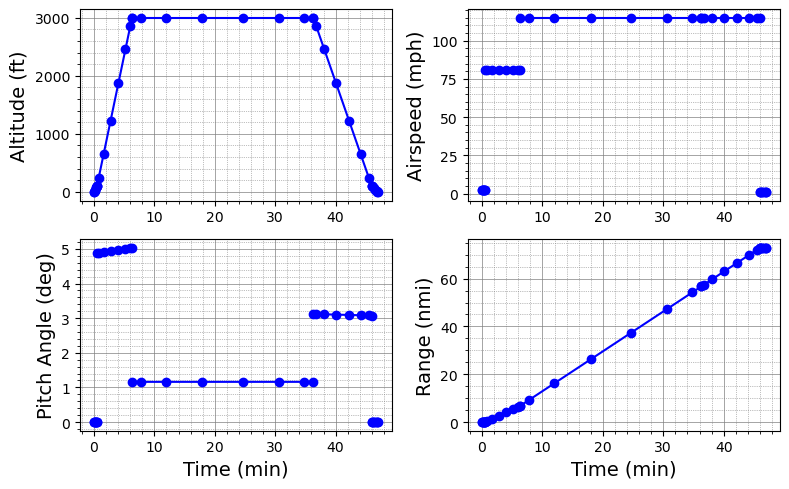

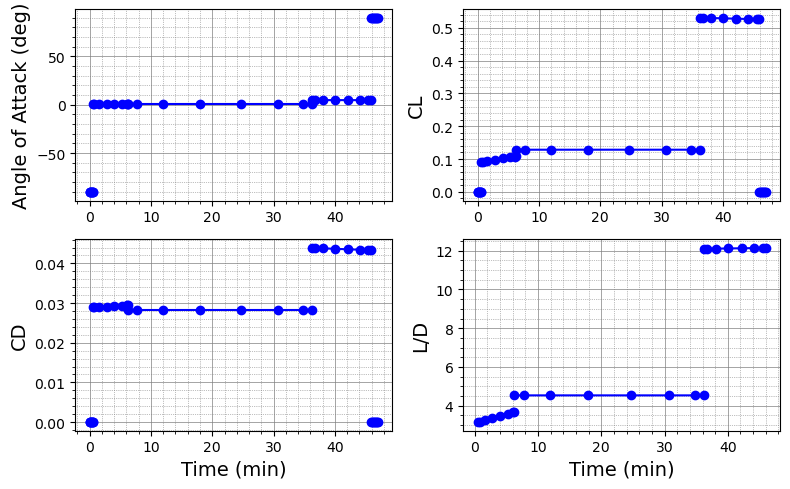

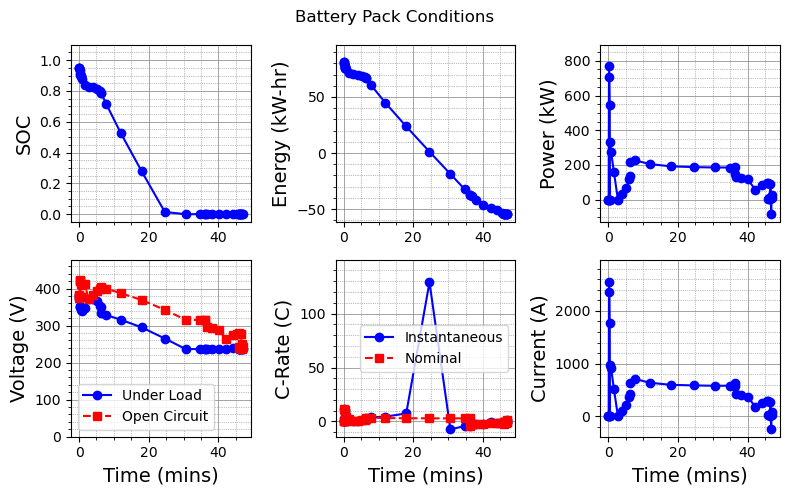

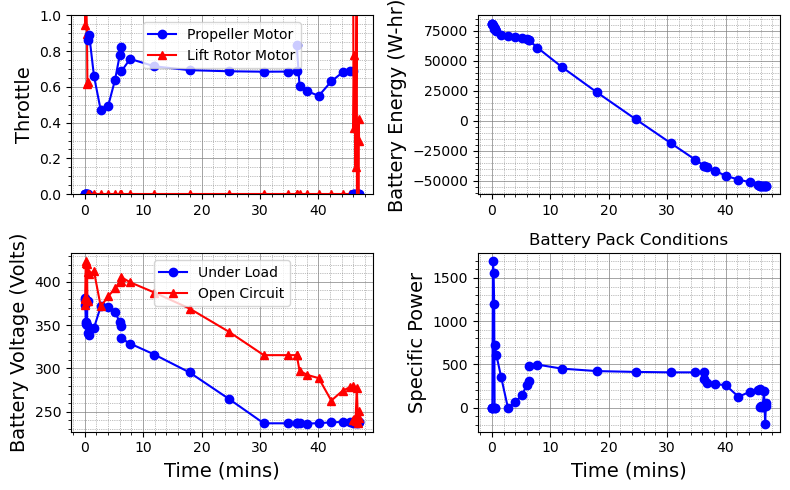

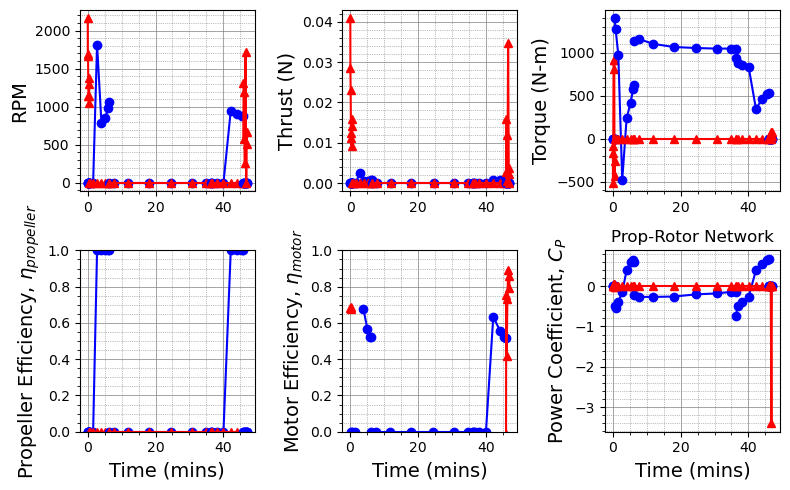

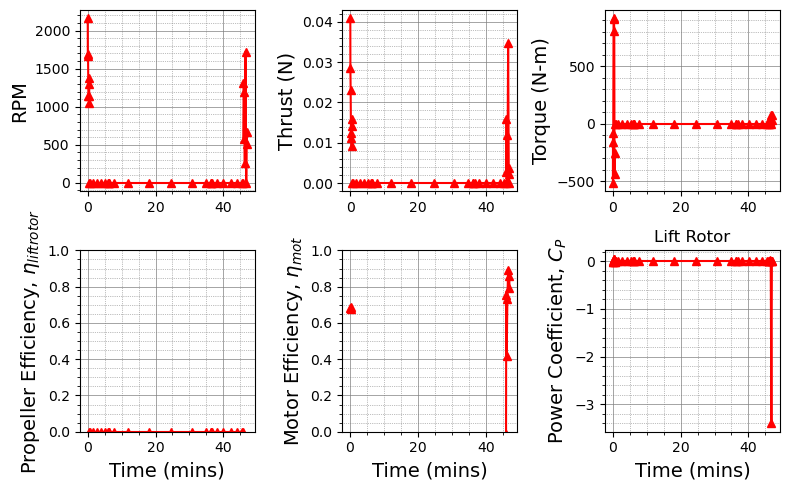

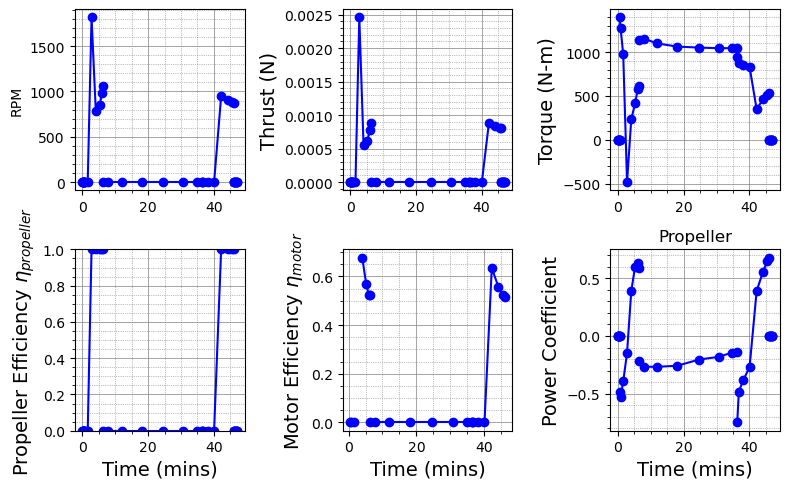

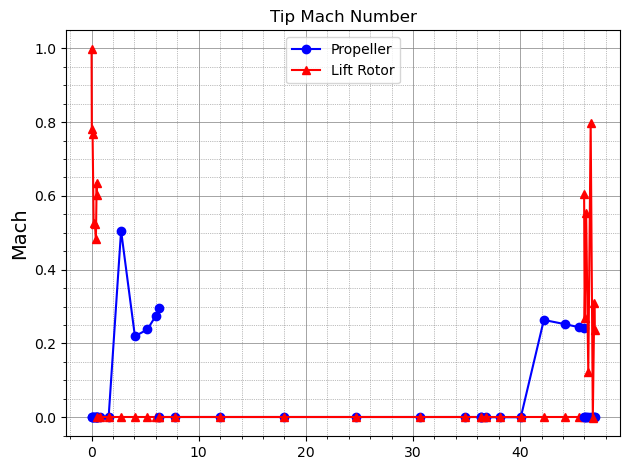

In [6]:
# Setup a vehicle
vehicle = setup_vehicle()

# # Ensure the NMC battery response-surface data is available in this environment
# battery = vehicle.networks.lift_cruise.battery
# if getattr(battery, 'discharge_performance_map', None) is None:
#     nmc_data_path = Path(r'd:/Workspace/SUAVE-2.5.2/trunk/SUAVE/Components/Energy/Storages/Batteries/Constant_Mass/NMC_Raw_Data.res')
#     raw_data = SUAVE.Input_Output.SUAVE.load(str(nmc_data_path))
#     battery.discharge_performance_map = _nmc_mod.create_discharge_performance_map(raw_data)

# # export the vehicle
# #write(vehicle, 'our_eVTOL')

# Setup analyses
analyses = setup_analyses(vehicle)
analyses.finalize() #<- this builds surrogate models!

# Setup a mission
mission  = setup_mission(vehicle, analyses)

# Evaluate the mission
results = mission.evaluate()

# plot the mission
make_plots(results)
